# NARMAX Polinomial - Generalização (Mix de Sinais)

Este notebook treina um modelo NARMAX Polinomial usando o dataset misto (`F_Mix`),
que contém todos os tipos de sinais de excitação (APRBS, Multi-Seno, Swept-Sine, Degraus e Chirp).
O objetivo é obter o modelo mais robusto e generalista possível e extrair sua equação matemática.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime, os
from scipy.signal import decimate
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.metrics import r2_score

# Seed deterministica
np.random.seed(42)


## 1. PREPARAÇÃO DOS DADOS

In [ ]:
BASE = "https://raw.githubusercontent.com/FelipeEduardoMarcondes/SYSTEM-IDENTIFICATION-AERO/main/experimentos/"

F_MIX_FILES = [
    "aprbs-1_0827_17-19.csv", "aprbs-2_0827_17-25.csv", "aprbs-3_0827_17-28.csv", "aprbs-4_0827_17-31.csv",
    "RODADA-4/aprbs-2_0819_18-51.csv", "RODADA-4/swept-sine-1_0819_19-02.csv",
    "multi-seno-1_0827_17-34.csv", "multi-seno-2_0827_17-37.csv", "multi-seno-3_0827_17-40.csv", "multi-seno-4_0827_17-43.csv",
    "swept-sine-1_0827_17-58.csv", "swept-sine-4_0827_18-00.csv",
    "seq-degraus-1_0827_17-46.csv", "seq-degraus-2_0827_17-49.csv", "seq-degraus-3_0827_17-52.csv", "seq-degraus-4_0827_17-55.csv",
    "RODADA-3/chirp-1_0807_16-34.csv", "RODADA-3/chirp-2_0807_17-07.csv", "RODADA-3/chirp-2_0807_17-09.csv"
]
TEST_FILES_BY_TYPE = {
    "APRBS":     "RODADA-3/seq-degraus-aprbs-2_0807_17-23.csv",
    "MultiSeno": "RODADA-2/multi-seno-1_0804_19-06.csv",
    "Degraus":   "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "Chirp":     "RODADA-2/chirp-1_0804_19-19.csv",
}

DECIMACAO = 1
START_IDX = 200
END_IDX   = -200

scaler_u = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))
scaler_u.fit(np.array([[-100], [100]]))
scaler_y.fit(np.array([[-180], [180]]))

def carregar_experimento(url, decimacao=DECIMACAO, start_idx=START_IDX, end_idx=END_IDX):
    df = pd.read_csv(url)
    if 'referencia' in df.columns:
        df = df[df['referencia'] > 0]
    u_full = df['u_pct'].values.astype(np.float64) if 'u_pct' in df.columns else df['motor_percent'].values.astype(np.float64)
    y_full = df['angulo_deg'].values.astype(np.float64)
    
    if decimacao > 1:
        y_raw = decimate(y_full, decimacao, ftype='iir', zero_phase=True)
        u_raw = u_full[::decimacao]
    else:
        u_raw, y_raw = u_full, y_full
        
    dt = 0.010 * decimacao
    t_raw = np.arange(len(y_raw)) * dt
    min_l = min(len(y_raw), len(u_raw))
    t_raw, u_raw, y_raw = t_raw[:min_l], u_raw[:min_l], y_raw[:min_l]
    
    if start_idx is not None and end_idx is not None:
        t_raw = t_raw[start_idx:end_idx]
        u_raw = u_raw[start_idx:end_idx]
        y_raw = y_raw[start_idx:end_idx]
        
    t_raw = t_raw - t_raw[0]
    return t_raw, u_raw, y_raw

def processar_dataset(t_raw, u_raw, y_raw):
    u_norm = scaler_u.transform(u_raw.reshape(-1, 1)).flatten()
    y_norm = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()
    return t_raw, u_norm, y_norm, u_raw, y_raw

def carregar_lista(file_list):
    datasets = []
    for f in file_list:
        t, u_raw, y_raw = carregar_experimento(BASE + f)
        t, u_norm, y_norm, _, _ = processar_dataset(t, u_raw, y_raw)
        datasets.append({
            'name': os.path.basename(f),
            't': t, 'u_norm': u_norm, 'y_norm': y_norm,
            'u_raw': u_raw, 'y_raw': y_raw
        })
    return datasets


## 2. CLASSE NARMAX POLINOMIAL (FROLS/OMP)

In [42]:
class MyPolyNARX:
    def __init__(self, ny=5, nu=5, degree=2, n_components=15):
        self.ny = ny
        self.nu = nu
        self.degree = degree
        self.n_components = n_components
        self.p = max(ny, nu)
        
        self.poly = PolynomialFeatures(degree=self.degree, include_bias=False)
        self.omp = OrthogonalMatchingPursuit(n_nonzero_coefs=self.n_components)
        self.feature_names_base = [f"y(k-{i})" for i in range(1, self.ny+1)] + [f"u(k-{i})" for i in range(1, self.nu+1)]

    def _extract_blocks(self, y, u):
        N = len(y)
        X = []
        Y = []
        for k in range(self.p, N):
            row = []
            for i in range(1, self.ny+1):
                row.append(y[k-i])
            for i in range(1, self.nu+1):
                row.append(u[k-i])
            X.append(row)
            Y.append(y[k])
        return np.array(X), np.array(Y)

    def fit(self, datasets):
        X_all = []
        Y_all = []
        for ds in datasets:
            X, Y = self._extract_blocks(ds['y_norm'], ds['u_norm'])
            X_all.append(X)
            Y_all.append(Y)
            
        X_all = np.vstack(X_all)
        Y_all = np.concatenate(Y_all)
        
        X_poly = self.poly.fit_transform(X_all)
        self.omp.fit(X_poly, Y_all)
        
    def predict(self, u, y_history):
        N = len(u)
        yhat = np.zeros(N)
        yhat[:self.p] = y_history[:self.p]
        
        for k in range(self.p, N):
            row = []
            for i in range(1, self.ny+1):
                row.append(yhat[k-i])
            for i in range(1, self.nu+1):
                row.append(u[k-i])
            
            X_feat = np.array([row])
            X_poly = self.poly.transform(X_feat)
            yhat[k] = self.omp.predict(X_poly)[0]
            # Clipping para evitar explosões numéricas
            yhat[k] = np.clip(yhat[k], -10.0, 10.0)
            
        return yhat
        
    def print_equations(self):
        poly_names = self.poly.get_feature_names_out(self.feature_names_base)
        coefs = self.omp.coef_
        intercept = self.omp.intercept_
        
        print("\n--- EQUAÇÃO NARMAX OBTIDA ---")
        print(f"y(k) = {intercept:.6f} (bias)")
        nonzero_idx = np.nonzero(coefs)[0]
        sorted_idx = sorted(nonzero_idx, key=lambda i: abs(coefs[i]), reverse=True)
        
        for idx in sorted_idx:
            term_name = poly_names[idx].replace(" ", " * ")
            val = coefs[idx]
            sign = "+" if val >= 0 else "-"
            print(f"       {sign} {abs(val):.6f} * [{term_name}]")
            print("-----------------------------\n")
        
        # Salvar equação em um arquivo txt
        with open("equacao_narx.txt", "w", encoding="utf-8") as f_eq:
            f_eq.write(f"y(k) = {intercept:.6f} (bias)\n")
            for idx in sorted_idx:
                term_name = poly_names[idx].replace(" ", " * ")
                val = coefs[idx]
                sign = "+" if val >= 0 else "-"
                f_eq.write(f"       {sign} {abs(val):.6f} * [{term_name}]\n")
        print("-> Equação foi salva com sucesso no arquivo 'equacao_narx.txt'.\n")

def avalia_free_run_poli(model, datasets):
    resultados = []
    for ds in datasets:
        y_norm = ds['y_norm']
        u_norm = ds['u_norm']
        
        y_pred_norm = model.predict(u_norm, y_history=y_norm[:model.p])
        
        y_real = ds['y_raw']
        y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
        
        y_real_valid = y_real[model.p:]
        y_pred_valid = y_pred[model.p:]
        t_valid = ds['t'][model.p:]
        
        rmse = float(np.sqrt(np.mean((y_pred_valid - y_real_valid) ** 2)))
        r2 = float(r2_score(y_real_valid, y_pred_valid))
        fit = float((1 - np.linalg.norm(y_pred_valid - y_real_valid) / (np.linalg.norm(y_real_valid - np.mean(y_real_valid)) + 1e-12)) * 100)
        
        resultados.append({
            'name': ds['name'], 'rmse': rmse, 'r2': r2, 'fit': fit,
            'y_real': y_real_valid, 'y_pred': y_pred_valid, 't': t_valid
        })
    return resultados


## 3. TREINAMENTO E AVALIAÇÃO (F_MIX)

Carregando dataset misto (F_Mix) de treinamento...


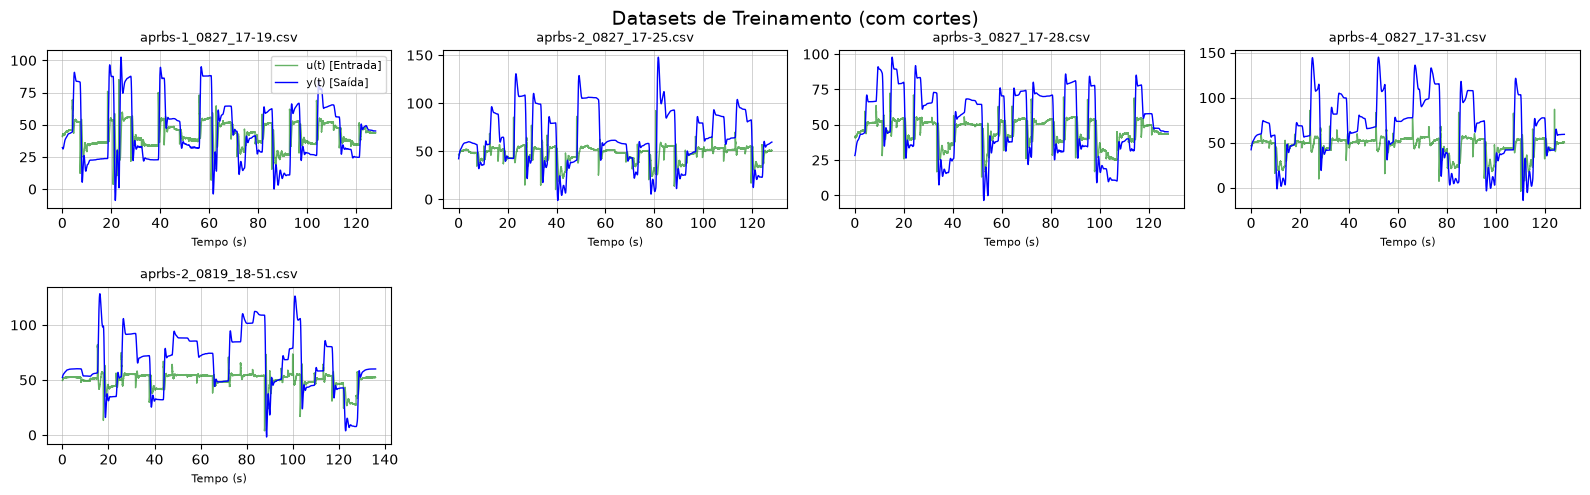

Carregando conjuntos de Teste (Cross-Session)...


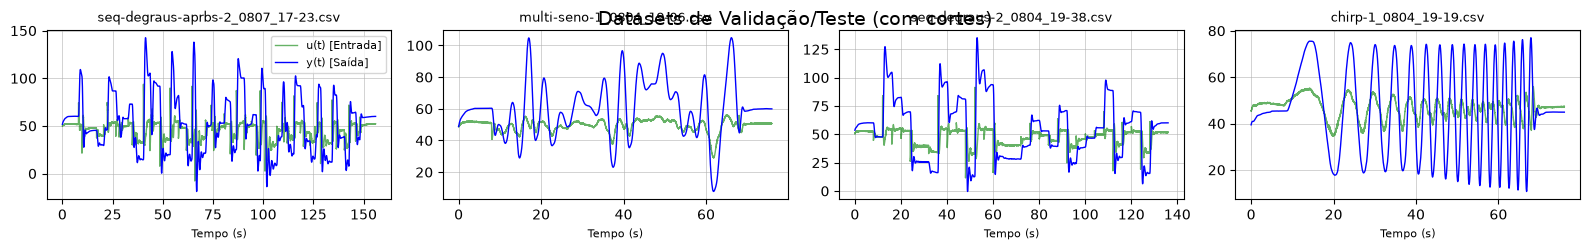


Treinando NARMAX (ny=80, nu=80, degree=2, termos=100)...

--- EQUAÇÃO NARMAX OBTIDA ---
y(k) = -0.000051 (bias)
       + 1.064187 * [y(k-1)]
-----------------------------

       - 0.078876 * [y(k-22)]
-----------------------------

       - 0.022010 * [y(k-9) * u(k-13)]
-----------------------------

       + 0.021631 * [y(k-39) * u(k-13)]
-----------------------------

       + 0.013013 * [y(k-52)]
-----------------------------

       - 0.007785 * [y(k-17) * y(k-47)]
-----------------------------

       + 0.006914 * [y(k-1)^2]
-----------------------------

       - 0.006566 * [y(k-9) * u(k-58)]
-----------------------------

       - 0.006219 * [y(k-68) * u(k-17)]
-----------------------------

       + 0.004837 * [y(k-1) * u(k-18)]
-----------------------------

       + 0.004209 * [u(k-17) * u(k-68)]
-----------------------------

       + 0.003930 * [y(k-37) * u(k-58)]
-----------------------------

       - 0.003559 * [y(k-75) * u(k-5)]
-----------------------------

       +

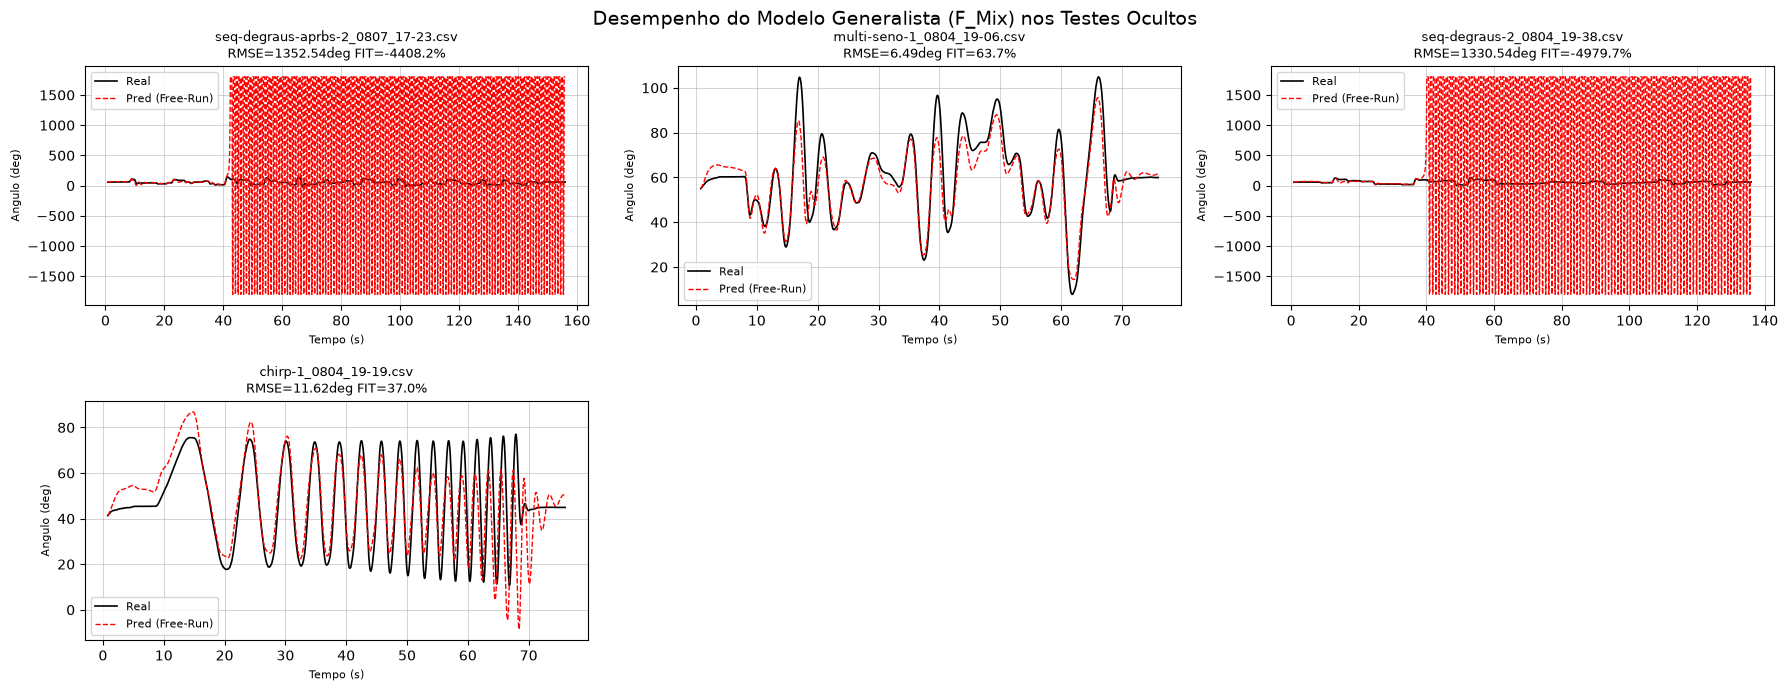

In [43]:
from IPython.utils import frame
from IPython.utils import frame
from IPython.utils import frame
from IPython.utils import frame
from IPython.utils import frame
from IPython.utils import frame
from IPython.utils import frame
def plot_datasets_grid(datasets_list, title):
    n = len(datasets_list)
    cols = min(4, n)
    rows = -(-n // cols)
    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows))
    fig.suptitle(title, fontsize=14)
    
    # Garantir que axs seja 2D para iteração segura
    if n == 1:
        axs = np.array([[axs]])
    elif rows == 1:
        axs = np.array([axs])
        
    for i, ds in enumerate(datasets_list):
        ax = axs[i // cols, i % cols]
        ax.plot(ds['t'], ds['u_raw'], 'g-', lw=1, alpha=0.6, label='u(t) [Entrada]')
        ax.plot(ds['t'], ds['y_raw'], 'b-', lw=1, label='y(t) [Saída]')
        ax.set_title(ds['name'], fontsize=9)
        ax.set_xlabel('Tempo (s)', fontsize=8)
        if i == 0:
            ax.legend(fontsize=8)
        ax.grid(True, lw=0.4)
        
    for i in range(n, rows * cols):
        axs[i // cols, i % cols].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

if __name__ == '__main__':
    print("Carregando dataset misto (F_Mix) de treinamento...")
    train_datasets = carregar_lista(F_MIX_FILES)
    plot_datasets_grid(train_datasets, "Datasets de Treinamento (com cortes)")
    
    print("Carregando conjuntos de Teste (Cross-Session)...")
    test_datasets_flat = []
    test_por_tipo = {}
    for tipo, arquivo in TEST_FILES_BY_TYPE.items():
        ds = carregar_lista([arquivo])
        test_por_tipo[tipo] = ds
        test_datasets_flat.extend(ds)
        
    plot_datasets_grid(test_datasets_flat, "Datasets de Validação/Teste (com cortes)")
    
    ny, nu = 80, 80
    degree = 2
    n_components = 100
    
    print(f"\nTreinando NARMAX (ny={ny}, nu={nu}, degree={degree}, termos={n_components})...")
    model = MyPolyNARX(ny=ny, nu=nu, degree=degree, n_components=n_components)
    model.fit(train_datasets)
    
    # A Equação Matemática do modelo generalizado
    model.print_equations()
    
    print("\n--- AVALIAÇÃO FREE-RUN NOS TESTES ---")
    todos_resultados = []
    for tipo, dsl in test_por_tipo.items():
        res = avalia_free_run_poli(model, dsl)
        todos_resultados.extend(res)
        rmse_m = np.mean([r['rmse'] for r in res])
        r2_m = np.mean([r['r2'] for r in res])
        fit_m = np.mean([r['fit'] for r in res])
        print(f"[{tipo:<10}] RMSE: {rmse_m:5.2f} deg  |  R2: {r2_m:6.3f}  |  FIT: {fit_m:5.1f}%")
        
    # Plots
    n = len(todos_resultados)
    cols = min(3, n)
    rows = -(-n // cols)
    fig, axs = plt.subplots(rows, cols, figsize=(6 * cols, 3.5 * rows))
    fig.suptitle('Desempenho do Modelo Generalista (F_Mix) nos Testes Ocultos', fontsize=14)
    axs = np.array(axs).reshape(rows, cols) if n > 1 else np.array([[axs]])

    for i, r in enumerate(todos_resultados):
        ax = axs[i // cols, i % cols]
        ax.plot(r['t'], r['y_real'], 'k',   lw=1.2, label='Real')
        ax.plot(r['t'], r['y_pred'], 'r--', lw=1.0, label='Pred (Free-Run)')
        ax.set_title(f"{r['name']}\nRMSE={r['rmse']:.2f}deg FIT={r['fit']:.1f}%", fontsize=9)
        ax.set_xlabel('Tempo (s)', fontsize=8)
        ax.set_ylabel('Angulo (deg)', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, lw=0.4)

    for i in range(n, rows * cols):
        axs[i // cols, i % cols].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()
